# Chapter 8.7: Cross-Platform & Cross-Domain Recommendation

## Learning Objectives

By the end of this notebook, you will be able to:

1. Understand the motivation and challenges of cross-domain recommendation
2. Implement transfer learning across different recommendation surfaces
3. Design shared user embedding systems across domains
4. Apply domain adaptation techniques (MMD, adversarial alignment)
5. Understand privacy constraints in cross-platform transfer
6. Build a cross-domain recommendation system with shared user embeddings
7. Evaluate transfer effectiveness across domains

## Prerequisites

- Chapter 8.4-8.5: User and item modeling
- Basic understanding of domain adaptation
- Familiarity with multi-task learning

[![Open In Colab](https://colab.research.google.com/assets/colab-badge.svg)](https://colab.research.google.com/github/hideak1/rec_system/blob/main/notebooks/part8/chapter_8.7_cross_domain.ipynb)
[![Download](https://img.shields.io/badge/Download-Notebook-blue)](https://github.com/hideak1/rec_system/raw/main/notebooks/part8/chapter_8.7_cross_domain.ipynb)

In [1]:
import torch
import torch.nn as nn
import torch.nn.functional as F
import numpy as np
import matplotlib.pyplot as plt
from typing import Dict, List, Tuple, Optional
from dataclasses import dataclass
from collections import defaultdict

torch.manual_seed(42)
np.random.seed(42)

plt.style.use('seaborn-v0_8')
print(f"PyTorch version: {torch.__version__}")

PyTorch version: 2.2.2


## 1. Why Cross-Domain Recommendation?

Major tech companies operate multiple products:
- **Tencent**: WeChat, QQ, Tencent Video, QQ Music
- **Meta**: Facebook, Instagram, WhatsApp
- **Amazon**: Retail, Prime Video, Music, Kindle
- **Google**: YouTube, Play Store, Search, Maps

A user's behavior on one platform reveals preferences useful on another. For example:
- A user watching cooking videos on YouTube might like kitchen gadgets on Shopping
- A user reading sci-fi on Kindle might enjoy sci-fi movies on Prime Video

The main challenges:
1. **Feature space mismatch**: Different domains have different items and features
2. **Distribution shift**: User behavior patterns differ across domains
3. **Partial overlap**: Not all users are active on all platforms
4. **Privacy**: User data from one product shouldn't leak to another without consent

> **\U0001f4a1 Concept:** Cross-domain recommendation is particularly valuable for **cold-start** users. A new user on Tencent Video can get personalized recommendations from day one if they have a rich history on WeChat.

In [2]:
# Simulate two domains with shared users

@dataclass
class DomainData:
    name: str
    num_items: int
    num_categories: int
    item_categories: np.ndarray
    user_item_interactions: Dict[int, List[int]]  # user_id -> [item_ids]

def generate_cross_domain_data(
    num_shared_users: int = 3000,
    num_domain_a_only: int = 1000,
    num_domain_b_only: int = 1000,
    num_items_a: int = 500,
    num_items_b: int = 400,
    num_cats_a: int = 10,
    num_cats_b: int = 8,
) -> Tuple[DomainData, DomainData, np.ndarray]:
    """
    Generate synthetic cross-domain data.
    Users have latent preferences that manifest differently in each domain.
    """
    total_users = num_shared_users + num_domain_a_only + num_domain_b_only
    
    # Latent user preferences (shared across domains)
    latent_dim = 5
    user_latent = np.random.randn(total_users, latent_dim)
    
    # Domain A: maps latent preferences to categories
    cat_a = np.random.randint(0, num_cats_a, num_items_a)
    cat_to_latent_a = np.random.randn(num_cats_a, latent_dim) * 0.5
    
    # Domain B: different mapping from same latent space
    cat_b = np.random.randint(0, num_cats_b, num_items_b)
    cat_to_latent_b = np.random.randn(num_cats_b, latent_dim) * 0.5
    
    # Generate interactions
    users_in_a = list(range(num_shared_users + num_domain_a_only))  # shared + A-only
    users_in_b = list(range(num_shared_users)) + list(range(
        num_shared_users + num_domain_a_only, total_users
    ))  # shared + B-only
    
    interactions_a = defaultdict(list)
    for uid in users_in_a:
        # Probability of interacting with each item based on latent similarity
        for item_id in range(num_items_a):
            cat = cat_a[item_id]
            score = user_latent[uid] @ cat_to_latent_a[cat]
            if np.random.random() < 1.0 / (1.0 + np.exp(-score - 1)):
                interactions_a[uid].append(item_id)
    
    interactions_b = defaultdict(list)
    for uid in users_in_b:
        for item_id in range(num_items_b):
            cat = cat_b[item_id]
            score = user_latent[uid] @ cat_to_latent_b[cat]
            if np.random.random() < 1.0 / (1.0 + np.exp(-score - 1)):
                interactions_b[uid].append(item_id)
    
    domain_a = DomainData('shopping', num_items_a, num_cats_a, cat_a, dict(interactions_a))
    domain_b = DomainData('video', num_items_b, num_cats_b, cat_b, dict(interactions_b))
    
    return domain_a, domain_b, user_latent

domain_a, domain_b, user_latent = generate_cross_domain_data()

print(f"Domain A ({domain_a.name}): {domain_a.num_items} items, {len(domain_a.user_item_interactions)} users")
print(f"Domain B ({domain_b.name}): {domain_b.num_items} items, {len(domain_b.user_item_interactions)} users")
print(f"\nShared users: 3000")
print(f"Avg interactions per user (A): {np.mean([len(v) for v in domain_a.user_item_interactions.values()]):.1f}")
print(f"Avg interactions per user (B): {np.mean([len(v) for v in domain_b.user_item_interactions.values()]):.1f}")

Domain A (shopping): 500 items, 4000 users
Domain B (video): 400 items, 4000 users

Shared users: 3000
Avg interactions per user (A): 349.4
Avg interactions per user (B): 278.9


## 2. Shared User Embedding Architecture

The simplest cross-domain approach: learn a **shared user embedding** that works across domains.

Architecture:
1. **Shared encoder**: Maps user features to a domain-agnostic representation
2. **Domain-specific heads**: Transform shared embedding for each domain's task

$$\mathbf{u}_{\text{shared}} = f_{\text{shared}}(\text{user\_features})$$
$$\hat{y}_A = g_A(\mathbf{u}_{\text{shared}}, \mathbf{e}_i^A), \quad \hat{y}_B = g_B(\mathbf{u}_{\text{shared}}, \mathbf{e}_j^B)$$

> **\U0001f511 Pro Tip:** Tencent's approach (Zhu et al., 2021) uses a shared user ID embedding table across WeChat and QQ, with domain-specific transformation layers. The shared embedding captures "who you are" while the domain layers capture "what you do here."

In [3]:
class CrossDomainRecommender(nn.Module):
    """Cross-domain recommender with shared user embeddings."""
    
    def __init__(
        self,
        num_users: int,
        num_items_a: int,
        num_items_b: int,
        shared_dim: int = 32,
        domain_dim: int = 32,
    ):
        super().__init__()
        
        # Shared user embedding
        self.user_shared_emb = nn.Embedding(num_users, shared_dim)
        
        # Domain-specific item embeddings
        self.item_emb_a = nn.Embedding(num_items_a, domain_dim)
        self.item_emb_b = nn.Embedding(num_items_b, domain_dim)
        
        # Domain-specific user adaptation layers
        self.user_adapter_a = nn.Sequential(
            nn.Linear(shared_dim, domain_dim),
            nn.ReLU(),
            nn.Linear(domain_dim, domain_dim),
        )
        self.user_adapter_b = nn.Sequential(
            nn.Linear(shared_dim, domain_dim),
            nn.ReLU(),
            nn.Linear(domain_dim, domain_dim),
        )
        
        nn.init.xavier_uniform_(self.user_shared_emb.weight)
        nn.init.xavier_uniform_(self.item_emb_a.weight)
        nn.init.xavier_uniform_(self.item_emb_b.weight)
    
    def forward_domain(
        self, user_ids: torch.Tensor, item_ids: torch.Tensor, domain: str
    ) -> torch.Tensor:
        shared_emb = self.user_shared_emb(user_ids)
        
        if domain == 'A':
            user_emb = self.user_adapter_a(shared_emb)
            item_emb = self.item_emb_a(item_ids)
        else:
            user_emb = self.user_adapter_b(shared_emb)
            item_emb = self.item_emb_b(item_ids)
        
        return (user_emb * item_emb).sum(dim=-1)
    
    def get_shared_embedding(self, user_ids: torch.Tensor) -> torch.Tensor:
        return self.user_shared_emb(user_ids)

# Prepare training data
total_users = 5000

def prepare_training_pairs(domain_data: DomainData, neg_ratio: int = 4):
    users, items, labels = [], [], []
    for uid, pos_items in domain_data.user_item_interactions.items():
        for item_id in pos_items:
            users.append(uid)
            items.append(item_id)
            labels.append(1.0)
            # Negative samples
            for _ in range(neg_ratio):
                neg_item = np.random.randint(0, domain_data.num_items)
                users.append(uid)
                items.append(neg_item)
                labels.append(0.0)
    return torch.tensor(users), torch.tensor(items), torch.tensor(labels)

train_users_a, train_items_a, train_labels_a = prepare_training_pairs(domain_a)
train_users_b, train_items_b, train_labels_b = prepare_training_pairs(domain_b)

# Limit dataset size for demo
max_samples = 30000
if len(train_users_a) > max_samples:
    idx = torch.randperm(len(train_users_a))[:max_samples]
    train_users_a, train_items_a, train_labels_a = train_users_a[idx], train_items_a[idx], train_labels_a[idx]
if len(train_users_b) > max_samples:
    idx = torch.randperm(len(train_users_b))[:max_samples]
    train_users_b, train_items_b, train_labels_b = train_users_b[idx], train_items_b[idx], train_labels_b[idx]

print(f"Domain A training: {len(train_users_a)} pairs")
print(f"Domain B training: {len(train_users_b)} pairs")

# Train cross-domain model
cross_model = CrossDomainRecommender(total_users, domain_a.num_items, domain_b.num_items)
optimizer = torch.optim.Adam(cross_model.parameters(), lr=0.005)

batch_size = 512
losses_a, losses_b = [], []

for epoch in range(8):
    # Alternate between domains
    perm_a = torch.randperm(len(train_users_a))
    perm_b = torch.randperm(len(train_users_b))
    
    epoch_loss_a, epoch_loss_b = 0, 0
    n_a, n_b = 0, 0
    
    max_batches = min(len(perm_a), len(perm_b)) // batch_size
    for batch_idx in range(max_batches):
        # Domain A batch
        idx_a = perm_a[batch_idx*batch_size:(batch_idx+1)*batch_size]
        scores_a = cross_model.forward_domain(train_users_a[idx_a], train_items_a[idx_a], 'A')
        loss_a = F.binary_cross_entropy_with_logits(scores_a, train_labels_a[idx_a])
        
        # Domain B batch
        idx_b = perm_b[batch_idx*batch_size:(batch_idx+1)*batch_size]
        scores_b = cross_model.forward_domain(train_users_b[idx_b], train_items_b[idx_b], 'B')
        loss_b = F.binary_cross_entropy_with_logits(scores_b, train_labels_b[idx_b])
        
        # Joint optimization
        total_loss = loss_a + loss_b
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        epoch_loss_a += loss_a.item()
        epoch_loss_b += loss_b.item()
        n_a += 1
        n_b += 1
    
    losses_a.append(epoch_loss_a / max(n_a, 1))
    losses_b.append(epoch_loss_b / max(n_b, 1))

print(f"Final loss A: {losses_a[-1]:.4f}, B: {losses_b[-1]:.4f}")

Domain A training: 30000 pairs
Domain B training: 30000 pairs


Final loss A: 0.3468, B: 0.2974


## 3. Domain Adaptation with MMD

**Maximum Mean Discrepancy (MMD)** is a statistical distance between distributions. We can use it to align user embeddings across domains:

$$\text{MMD}^2(P, Q) = \mathbb{E}_{x,x' \sim P}[k(x, x')] - 2\mathbb{E}_{x \sim P, y \sim Q}[k(x, y)] + \mathbb{E}_{y,y' \sim Q}[k(y, y')]$$

where $k$ is a kernel function (typically Gaussian RBF).

By minimizing MMD between domain-A and domain-B user embeddings, we encourage the shared space to be domain-agnostic.

> **\u26a0\ufe0f Common Pitfall:** Too much alignment can destroy domain-specific information. Use a balanced weight for the MMD loss -- typically 0.01-0.1 of the main task loss.

In [4]:
def gaussian_kernel(x: torch.Tensor, y: torch.Tensor, sigma: float = 1.0) -> torch.Tensor:
    """Compute Gaussian RBF kernel."""
    dist = torch.cdist(x, y, p=2)
    return torch.exp(-dist ** 2 / (2 * sigma ** 2))

def compute_mmd(x: torch.Tensor, y: torch.Tensor, sigma: float = 1.0) -> torch.Tensor:
    """Compute MMD between two sets of embeddings."""
    k_xx = gaussian_kernel(x, x, sigma).mean()
    k_yy = gaussian_kernel(y, y, sigma).mean()
    k_xy = gaussian_kernel(x, y, sigma).mean()
    return k_xx + k_yy - 2 * k_xy

class CrossDomainWithMMD(CrossDomainRecommender):
    """Cross-domain recommender with MMD alignment."""
    
    def compute_alignment_loss(
        self, users_a: torch.Tensor, users_b: torch.Tensor, sigma: float = 1.0
    ) -> torch.Tensor:
        """Compute MMD between embeddings of users from two domains."""
        emb_a = self.get_shared_embedding(users_a)
        emb_b = self.get_shared_embedding(users_b)
        return compute_mmd(emb_a, emb_b, sigma)

# Train with MMD alignment
mmd_model = CrossDomainWithMMD(total_users, domain_a.num_items, domain_b.num_items)
optimizer = torch.optim.Adam(mmd_model.parameters(), lr=0.005)

mmd_weight = 0.1
losses_mmd = {'domain_a': [], 'domain_b': [], 'mmd': []}

# Get shared users for alignment
shared_user_ids = torch.arange(0, 3000)

for epoch in range(8):
    perm_a = torch.randperm(len(train_users_a))
    perm_b = torch.randperm(len(train_users_b))
    epoch_losses = defaultdict(float)
    n_batches = 0
    
    max_batches = min(len(perm_a), len(perm_b)) // batch_size
    for batch_idx in range(max_batches):
        idx_a = perm_a[batch_idx*batch_size:(batch_idx+1)*batch_size]
        idx_b = perm_b[batch_idx*batch_size:(batch_idx+1)*batch_size]
        
        # Task losses
        scores_a = mmd_model.forward_domain(train_users_a[idx_a], train_items_a[idx_a], 'A')
        loss_a = F.binary_cross_entropy_with_logits(scores_a, train_labels_a[idx_a])
        
        scores_b = mmd_model.forward_domain(train_users_b[idx_b], train_items_b[idx_b], 'B')
        loss_b = F.binary_cross_entropy_with_logits(scores_b, train_labels_b[idx_b])
        
        # MMD alignment loss (sample shared users)
        sample_size = min(128, len(shared_user_ids))
        sample_idx = shared_user_ids[torch.randperm(len(shared_user_ids))[:sample_size]]
        mmd_loss = mmd_model.compute_alignment_loss(sample_idx[:sample_size//2], sample_idx[sample_size//2:])
        
        total_loss = loss_a + loss_b + mmd_weight * mmd_loss
        optimizer.zero_grad()
        total_loss.backward()
        optimizer.step()
        
        epoch_losses['domain_a'] += loss_a.item()
        epoch_losses['domain_b'] += loss_b.item()
        epoch_losses['mmd'] += mmd_loss.item()
        n_batches += 1
    
    for k in epoch_losses:
        losses_mmd[k].append(epoch_losses[k] / max(n_batches, 1))

print(f"Final losses - A: {losses_mmd['domain_a'][-1]:.4f}, "
      f"B: {losses_mmd['domain_b'][-1]:.4f}, "
      f"MMD: {losses_mmd['mmd'][-1]:.6f}")

Final losses - A: 0.3676, B: 0.3372, MMD: 0.014729


Hit@20 (shared users, domain B):
  Without MMD: 0.6915
  With MMD:    0.7043


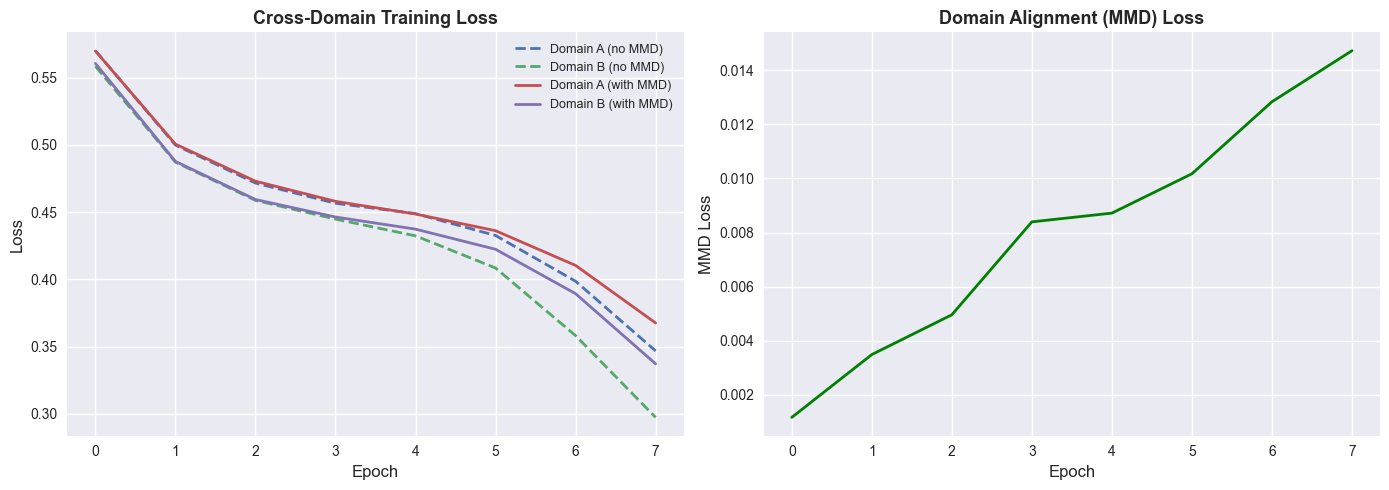

In [5]:
# Evaluate cross-domain transfer
def evaluate_cross_domain_transfer(model, domain_data, domain_label, cold_users):
    """Evaluate recommendation quality for users cold in this domain."""
    hits = 0
    total = 0
    
    for uid in cold_users:
        if uid not in domain_data.user_item_interactions:
            continue
        true_items = set(domain_data.user_item_interactions[uid])
        if len(true_items) < 2:
            continue
        
        # Score all items
        user_tensor = torch.tensor([uid]).expand(domain_data.num_items)
        item_tensor = torch.arange(domain_data.num_items)
        
        with torch.no_grad():
            scores = model.forward_domain(user_tensor, item_tensor, domain_label)
        
        # Check Hit@20
        top_20 = scores.topk(20).indices.tolist()
        hits += len(set(top_20) & true_items)
        total += min(20, len(true_items))
    
    return hits / max(total, 1)

# Cold users in domain B = users who are active in A but not B
users_a_only = list(range(3000, 4000))  # Only in domain A

# Compare models
hit_rate_base = evaluate_cross_domain_transfer(cross_model, domain_b, 'B', list(range(3000))[:200])
hit_rate_mmd = evaluate_cross_domain_transfer(mmd_model, domain_b, 'B', list(range(3000))[:200])

print(f"Hit@20 (shared users, domain B):")
print(f"  Without MMD: {hit_rate_base:.4f}")
print(f"  With MMD:    {hit_rate_mmd:.4f}")

# Visualize training
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(14, 5))

ax1.plot(losses_a, label='Domain A (no MMD)', linewidth=2, linestyle='--')
ax1.plot(losses_b, label='Domain B (no MMD)', linewidth=2, linestyle='--')
ax1.plot(losses_mmd['domain_a'], label='Domain A (with MMD)', linewidth=2)
ax1.plot(losses_mmd['domain_b'], label='Domain B (with MMD)', linewidth=2)
ax1.set_xlabel('Epoch', fontsize=12)
ax1.set_ylabel('Loss', fontsize=12)
ax1.set_title('Cross-Domain Training Loss', fontsize=13, fontweight='bold')
ax1.legend(fontsize=9)

ax2.plot(losses_mmd['mmd'], linewidth=2, color='green')
ax2.set_xlabel('Epoch', fontsize=12)
ax2.set_ylabel('MMD Loss', fontsize=12)
ax2.set_title('Domain Alignment (MMD) Loss', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('cross_domain_training.png', dpi=150, bbox_inches='tight')
plt.show()

## 4. Adversarial Domain Alignment

An alternative to MMD is **adversarial alignment**: train a discriminator to distinguish domain-A and domain-B user embeddings, and train the encoder to fool it.

$$\min_{\theta_{\text{enc}}} \max_{\theta_{\text{disc}}} \mathcal{L}_{\text{task}} + \lambda \mathcal{L}_{\text{adv}}$$

where $\mathcal{L}_{\text{adv}} = \mathbb{E}[\log D(f(x_A))] + \mathbb{E}[\log(1-D(f(x_B)))]$

> **\U0001f4a1 Concept:** The adversarial approach is inspired by GANs. If a discriminator can't tell which domain an embedding came from, the shared space must be truly domain-agnostic.

In [6]:
class DomainDiscriminator(nn.Module):
    """Discriminator that tries to distinguish domain A from domain B embeddings."""
    
    def __init__(self, input_dim: int, hidden_dim: int = 32):
        super().__init__()
        self.net = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, hidden_dim),
            nn.ReLU(),
            nn.Linear(hidden_dim, 1),
        )
    
    def forward(self, x: torch.Tensor) -> torch.Tensor:
        return self.net(x)

class GradientReversalLayer(torch.autograd.Function):
    """Reverses gradients during backward pass."""
    @staticmethod
    def forward(ctx, x, alpha):
        ctx.alpha = alpha
        return x.view_as(x)
    
    @staticmethod
    def backward(ctx, grad_output):
        return -ctx.alpha * grad_output, None

def gradient_reversal(x, alpha=1.0):
    return GradientReversalLayer.apply(x, alpha)

# Train with adversarial alignment
adv_model = CrossDomainRecommender(total_users, domain_a.num_items, domain_b.num_items)
discriminator = DomainDiscriminator(32)

optimizer_main = torch.optim.Adam(adv_model.parameters(), lr=0.005)
optimizer_disc = torch.optim.Adam(discriminator.parameters(), lr=0.01)

adv_losses = {'task': [], 'disc': []}

for epoch in range(8):
    perm_a = torch.randperm(len(train_users_a))
    perm_b = torch.randperm(len(train_users_b))
    epoch_task_loss, epoch_disc_loss = 0, 0
    n_batches = 0
    
    max_batches = min(len(perm_a), len(perm_b)) // batch_size
    for batch_idx in range(max_batches):
        idx_a = perm_a[batch_idx*batch_size:(batch_idx+1)*batch_size]
        idx_b = perm_b[batch_idx*batch_size:(batch_idx+1)*batch_size]
        
        # Step 1: Update discriminator
        with torch.no_grad():
            emb_a = adv_model.get_shared_embedding(train_users_a[idx_a])
            emb_b = adv_model.get_shared_embedding(train_users_b[idx_b])
        
        disc_pred_a = discriminator(emb_a)
        disc_pred_b = discriminator(emb_b)
        disc_loss = (
            F.binary_cross_entropy_with_logits(disc_pred_a, torch.ones_like(disc_pred_a)) +
            F.binary_cross_entropy_with_logits(disc_pred_b, torch.zeros_like(disc_pred_b))
        ) / 2
        
        optimizer_disc.zero_grad()
        disc_loss.backward()
        optimizer_disc.step()
        
        # Step 2: Update main model (with gradient reversal for adversarial)
        scores_a = adv_model.forward_domain(train_users_a[idx_a], train_items_a[idx_a], 'A')
        loss_a = F.binary_cross_entropy_with_logits(scores_a, train_labels_a[idx_a])
        
        scores_b = adv_model.forward_domain(train_users_b[idx_b], train_items_b[idx_b], 'B')
        loss_b = F.binary_cross_entropy_with_logits(scores_b, train_labels_b[idx_b])
        
        # Adversarial loss (fool the discriminator)
        emb_a_grad = adv_model.get_shared_embedding(train_users_a[idx_a])
        emb_b_grad = adv_model.get_shared_embedding(train_users_b[idx_b])
        emb_a_rev = gradient_reversal(emb_a_grad, alpha=0.1)
        emb_b_rev = gradient_reversal(emb_b_grad, alpha=0.1)
        
        disc_a_adv = discriminator(emb_a_rev)
        disc_b_adv = discriminator(emb_b_rev)
        adv_loss = (
            F.binary_cross_entropy_with_logits(disc_a_adv, torch.ones_like(disc_a_adv)) +
            F.binary_cross_entropy_with_logits(disc_b_adv, torch.zeros_like(disc_b_adv))
        ) / 2
        
        total_loss = loss_a + loss_b + adv_loss
        optimizer_main.zero_grad()
        total_loss.backward()
        optimizer_main.step()
        
        epoch_task_loss += (loss_a.item() + loss_b.item()) / 2
        epoch_disc_loss += disc_loss.item()
        n_batches += 1
    
    adv_losses['task'].append(epoch_task_loss / max(n_batches, 1))
    adv_losses['disc'].append(epoch_disc_loss / max(n_batches, 1))

print(f"Final task loss: {adv_losses['task'][-1]:.4f}")
print(f"Final discriminator loss: {adv_losses['disc'][-1]:.4f} (0.693 = random)")

Final task loss: 0.3090
Final discriminator loss: 0.6470 (0.693 = random)


## 5. Privacy Constraints in Cross-Platform Transfer

When transferring across platforms (especially different companies), privacy is paramount:

1. **Data cannot leave the platform**: Raw user behavior must stay within each platform
2. **Aggregated signals only**: Only aggregated, anonymized features can be shared
3. **Differential privacy**: Add noise to ensure individual actions are not recoverable
4. **Federated approach**: Train models locally, share only gradients or model updates

$$\text{Shared info} = \text{DP}(\text{aggregate}(\text{user\_behavior}))$$

> **\U0001f511 Pro Tip:** In practice, cross-platform transfer within the same company (e.g., YouTube to Google Shopping) faces fewer legal barriers than cross-company (e.g., Netflix to Spotify). Always consult with legal and privacy teams.

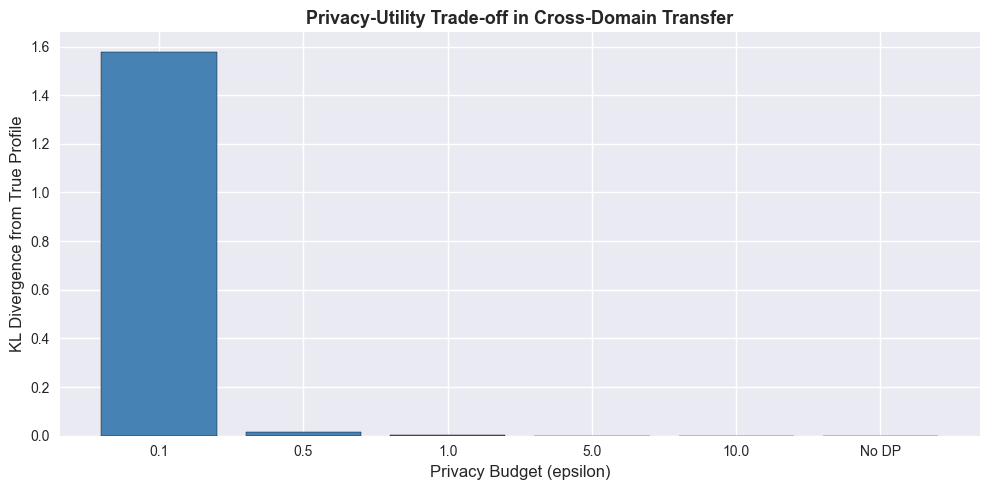

In [7]:
class PrivacyPreservingTransfer:
    """Simulates privacy-preserving cross-domain transfer."""
    
    def __init__(self, epsilon: float = 1.0, delta: float = 1e-5):
        self.epsilon = epsilon
        self.delta = delta
    
    def create_private_profile(
        self,
        user_interactions: List[int],
        item_categories: np.ndarray,
        num_categories: int,
    ) -> np.ndarray:
        """Create a DP-protected category preference profile."""
        # Aggregate to category counts
        cat_counts = np.zeros(num_categories)
        for item_id in user_interactions:
            if item_id < len(item_categories):
                cat_counts[item_categories[item_id]] += 1
        
        # Normalize
        total = cat_counts.sum()
        if total > 0:
            cat_probs = cat_counts / total
        else:
            cat_probs = np.ones(num_categories) / num_categories
        
        # Add Laplace noise for differential privacy
        sensitivity = 2.0 / max(total, 1)  # L1 sensitivity of normalized histogram
        noise_scale = sensitivity / self.epsilon
        noisy_probs = cat_probs + np.random.laplace(0, noise_scale, num_categories)
        
        # Project back to valid probability distribution
        noisy_probs = np.maximum(noisy_probs, 0)
        if noisy_probs.sum() > 0:
            noisy_probs /= noisy_probs.sum()
        else:
            noisy_probs = np.ones(num_categories) / num_categories
        
        return noisy_probs

# Compare profile quality at different epsilon values
epsilons = [0.1, 0.5, 1.0, 5.0, 10.0, float('inf')]
kl_divergences = []

test_user = 0
true_interactions = domain_a.user_item_interactions.get(test_user, [])

for eps in epsilons:
    kl_values = []
    for _ in range(100):  # Multiple trials
        if eps == float('inf'):
            transfer = PrivacyPreservingTransfer(epsilon=1e10)
        else:
            transfer = PrivacyPreservingTransfer(epsilon=eps)
        
        noisy_profile = transfer.create_private_profile(
            true_interactions, domain_a.item_categories, domain_a.num_categories
        )
        
        # True profile
        true_counts = np.zeros(domain_a.num_categories)
        for item_id in true_interactions:
            true_counts[domain_a.item_categories[item_id]] += 1
        true_profile = true_counts / max(true_counts.sum(), 1)
        true_profile = np.clip(true_profile, 1e-8, None)
        noisy_profile = np.clip(noisy_profile, 1e-8, None)
        
        kl = np.sum(true_profile * np.log(true_profile / noisy_profile))
        kl_values.append(kl)
    
    kl_divergences.append(np.mean(kl_values))

fig, ax = plt.subplots(figsize=(10, 5))
eps_labels = [str(e) if e != float('inf') else 'No DP' for e in epsilons]
ax.bar(range(len(epsilons)), kl_divergences, color='steelblue', edgecolor='black')
ax.set_xticks(range(len(epsilons)))
ax.set_xticklabels(eps_labels)
ax.set_xlabel('Privacy Budget (epsilon)', fontsize=12)
ax.set_ylabel('KL Divergence from True Profile', fontsize=12)
ax.set_title('Privacy-Utility Trade-off in Cross-Domain Transfer', fontsize=13, fontweight='bold')

plt.tight_layout()
plt.savefig('privacy_transfer.png', dpi=150, bbox_inches='tight')
plt.show()

## 6. Exercises

### \U0001f3cb\ufe0f Exercise 1: Multi-Domain Shared Embeddings

Extend the cross-domain system to support 3+ domains.

In [8]:
# Exercise 1: Multi-Domain System
# TODO: Implement a system that shares user embeddings across 3 domains

class MultiDomainRecommender(nn.Module):
    """
    Supports N domains with:
    - One shared user embedding
    - N domain-specific adapter layers
    - N domain-specific item embedding tables
    - Pairwise MMD alignment between all domain pairs
    """
    
    def __init__(
        self, num_users: int, domain_configs: List[Dict],
        shared_dim: int = 32
    ):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward_domain(
        self, user_ids: torch.Tensor, item_ids: torch.Tensor, domain_idx: int
    ) -> torch.Tensor:
        # TODO: Implement
        pass
    
    def compute_pairwise_mmd(self, domain_users: Dict[int, torch.Tensor]) -> torch.Tensor:
        # TODO: Compute MMD between all pairs of domains
        pass

### \U0001f3cb\ufe0f Exercise 2: Cold-Start Transfer Evaluation

Build a comprehensive evaluation for cross-domain cold-start.

In [9]:
# Exercise 2: Cold-Start Transfer Evaluation
# TODO: Evaluate how well cross-domain transfer helps cold-start users

def evaluate_cold_start_transfer(
    cross_model: CrossDomainRecommender,
    single_domain_model: nn.Module,  # Trained only on target domain
    target_domain: DomainData,
    cold_users: List[int],  # Users with no history in target domain
    k_values: List[int] = None,
) -> Dict[str, Dict[str, float]]:
    """
    Compare cross-domain vs single-domain models for cold-start users.
    
    Returns:
        Dict mapping model name to metrics (Hit@K, NDCG@K)
    """
    # TODO: Implement
    pass

### \U0001f3cb\ufe0f Exercise 3: Domain-Specific Feature Extraction

Implement a system that extracts domain-invariant and domain-specific features from user behavior.

In [10]:
# Exercise 3: Domain-Invariant Feature Extraction
# TODO: Disentangle domain-invariant from domain-specific features

class DisentangledUserEncoder(nn.Module):
    """
    Produces two outputs:
    - domain_invariant: captures universal preferences (transferable)
    - domain_specific: captures domain-specific behavior (not transferable)
    
    Uses orthogonality constraint to ensure the two are complementary.
    """
    
    def __init__(self, num_users: int, shared_dim: int, specific_dim: int):
        super().__init__()
        # TODO: Implement
        pass
    
    def forward(self, user_ids: torch.Tensor) -> Tuple[torch.Tensor, torch.Tensor]:
        # TODO: Return (invariant_emb, specific_emb)
        pass
    
    def orthogonality_loss(self, user_ids: torch.Tensor) -> torch.Tensor:
        # TODO: Penalize correlation between invariant and specific
        pass

## Summary

In this notebook, we explored cross-domain recommendation:

1. **Shared user embeddings**: A single user representation serving multiple domains
2. **MMD alignment**: Statistical distance minimization for domain adaptation
3. **Adversarial alignment**: Using a discriminator to enforce domain-agnostic embeddings
4. **Privacy-preserving transfer**: DP mechanisms for cross-platform feature sharing

### Key References

- Zhu et al. "Cross-Domain Recommendation with Large-Scale Shared User Representations" (Tencent, KDD 2021)
- Hu et al. "CoNet: Collaborative Cross Networks for Cross-Domain Recommendation" (2018)
- Liu et al. "A Unified Framework for Cross-Domain and Cross-System Recommendations" (IJCAI, 2020)
- Ganin et al. "Domain-Adversarial Training of Neural Networks" (JMLR, 2016)

### Next Steps

In Chapter 8.8, we will explore **Privacy-Preserving Features** including federated learning, differential privacy, and on-device personalization.